UPLOAD YOUR BRAIN TUMOR DATASET ZIP FILE


Saving classification_task.zip to classification_task.zip

Uploaded file: classification_task.zip

Extracting dataset...
Extraction completed.

DATASET FOLDERS FOUND
train : /content/brain_tumor_dataset/classification_task/train
test  : /content/brain_tumor_dataset/classification_task/test

DATASET SUMMARY

Class              Train Images     Test Images
------------------------------------------------
glioma                     1147             254
meningioma                 1329             306
no_tumor                   1067             140
pituitary                  1457             300
------------------------------------------------
TOTAL                      5000            1000

SAMPLE MRI IMAGES FROM TRAIN DATA


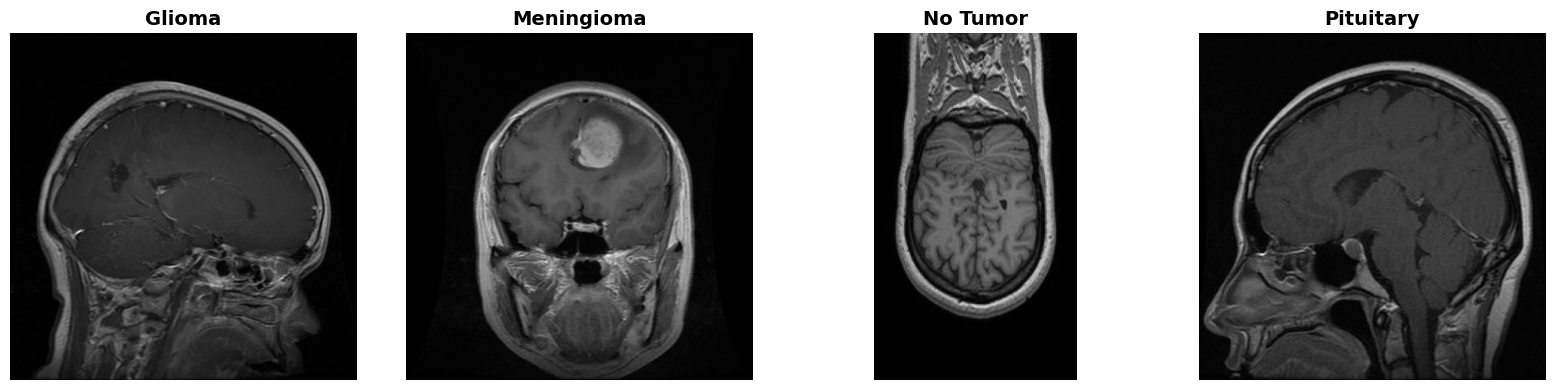


SAMPLE IMAGE INFORMATION

Class      : glioma
File       : brisc2025_train_00474_gl_co_t1.jpg
Dimensions : (512, 512)
Mode       : L

Class      : meningioma
File       : brisc2025_train_02246_me_sa_t1.jpg
Dimensions : (512, 512)
Mode       : RGB

Class      : no_tumor
File       : brisc2025_train_02952_no_co_t1.jpg
Dimensions : (216, 369)
Mode       : RGB

Class      : pituitary
File       : brisc2025_train_04517_pi_sa_t1.jpg
Dimensions : (512, 512)
Mode       : RGB

DATASET LOADING COMPLETED SUCCESSFULLY

Total Training Images : 5000
Total Testing Images  : 1000
Number of Classes     : 4

Classes:
  ✓ glioma
  ✓ meningioma
  ✓ no_tumor
  ✓ pituitary

Folder structure:
train/
 ├── glioma/
 ├── meningioma/
 ├── no_tumor/
 └── pituitary/

test/
 ├── glioma/
 ├── meningioma/
 ├── no_tumor/
 └── pituitary/

Ready for the next step: MRI normalization.


In [1]:
# ============================================================
# BRAIN TUMOR MRI DATASET - ZIP UPLOAD VERSION
# Structure: train/test -> 4 classes
# ============================================================

import os
import zipfile
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

# ============================================================
# 1. UPLOAD ZIP FILE
# ============================================================

print("=" * 70)
print("UPLOAD YOUR BRAIN TUMOR DATASET ZIP FILE")
print("=" * 70)

uploaded = files.upload()

zip_files = [
    filename for filename in uploaded.keys()
    if filename.lower().endswith(".zip")
]

if len(zip_files) == 0:
    raise FileNotFoundError(
        "No ZIP file found. Please upload your dataset as a .zip file."
    )

ZIP_PATH = os.path.join("/content", zip_files[0])

print(f"\nUploaded file: {zip_files[0]}")

# ============================================================
# 2. EXTRACT ZIP FILE
# ============================================================

EXTRACT_PATH = "/content/brain_tumor_dataset"

if os.path.exists(EXTRACT_PATH):
    shutil.rmtree(EXTRACT_PATH)

os.makedirs(EXTRACT_PATH, exist_ok=True)

print("\nExtracting dataset...")

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Extraction completed.")

# ============================================================
# 3. FIND train AND test FOLDERS
# ============================================================

def find_folder(root_path, folder_name):

    for root, dirs, files_in_folder in os.walk(root_path):

        for directory in dirs:

            if directory == folder_name:
                return os.path.join(root, directory)

    return None


# LOWERCASE train and test
TRAIN_DIR = find_folder(EXTRACT_PATH, "train")
TEST_DIR  = find_folder(EXTRACT_PATH, "test")

if TRAIN_DIR is None:
    raise FileNotFoundError(
        "\nFolder 'train' was not found inside the ZIP file."
    )

if TEST_DIR is None:
    raise FileNotFoundError(
        "\nFolder 'test' was not found inside the ZIP file."
    )

print("\n" + "=" * 70)
print("DATASET FOLDERS FOUND")
print("=" * 70)

print("train :", TRAIN_DIR)
print("test  :", TEST_DIR)

# ============================================================
# 4. DEFINE CLASSES
# ============================================================

CLASSES = [
    "glioma",
    "meningioma",
    "no_tumor",
    "pituitary"
]

IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
)

# ============================================================
# 5. FUNCTION TO GET IMAGES
# ============================================================

def get_images(folder):

    if not os.path.exists(folder):
        return []

    return [
        f for f in os.listdir(folder)
        if f.lower().endswith(IMAGE_EXTENSIONS)
    ]

# ============================================================
# 6. COUNT TRAIN AND TEST IMAGES
# ============================================================

train_counts = {}
test_counts = {}

print("\n" + "=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

for cls in CLASSES:

    train_class_path = os.path.join(TRAIN_DIR, cls)
    test_class_path = os.path.join(TEST_DIR, cls)

    train_images = get_images(train_class_path)
    test_images = get_images(test_class_path)

    train_counts[cls] = len(train_images)
    test_counts[cls] = len(test_images)

print("\n{:<15} {:>15} {:>15}".format(
    "Class",
    "Train Images",
    "Test Images"
))

print("-" * 48)

for cls in CLASSES:

    print("{:<15} {:>15} {:>15}".format(
        cls,
        train_counts[cls],
        test_counts[cls]
    ))

print("-" * 48)

total_train = sum(train_counts.values())
total_test = sum(test_counts.values())

print("{:<15} {:>15} {:>15}".format(
    "TOTAL",
    total_train,
    total_test
))

# ============================================================
# 7. SHOW ONE SAMPLE IMAGE FROM EACH CLASS
# ============================================================

print("\n" + "=" * 70)
print("SAMPLE MRI IMAGES FROM TRAIN DATA")
print("=" * 70)

plt.figure(figsize=(16, 4))

for i, cls in enumerate(CLASSES):

    class_path = os.path.join(TRAIN_DIR, cls)

    image_files = get_images(class_path)

    if len(image_files) == 0:

        print(f"WARNING: No images found for {cls}")
        continue

    # Random image
    image_name = random.choice(image_files)

    image_path = os.path.join(
        class_path,
        image_name
    )

    # Open image
    image = Image.open(image_path)

    # Convert to array
    image_array = np.array(image)

    # Plot
    plt.subplot(1, 4, i + 1)

    if image_array.ndim == 2:
        plt.imshow(image_array, cmap="gray")
    else:
        plt.imshow(image_array)

    plt.title(
        cls.replace("_", " ").title(),
        fontsize=14,
        fontweight="bold"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# 8. IMAGE INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("SAMPLE IMAGE INFORMATION")
print("=" * 70)

for cls in CLASSES:

    class_path = os.path.join(
        TRAIN_DIR,
        cls
    )

    image_files = get_images(class_path)

    if len(image_files) == 0:
        continue

    image_name = image_files[0]

    image_path = os.path.join(
        class_path,
        image_name
    )

    image = Image.open(image_path)

    print(f"\nClass      : {cls}")
    print(f"File       : {image_name}")
    print(f"Dimensions : {image.size}")
    print(f"Mode       : {image.mode}")

# ============================================================
# 9. FINAL STATUS
# ============================================================

print("\n" + "=" * 70)
print("DATASET LOADING COMPLETED SUCCESSFULLY")
print("=" * 70)

print(f"\nTotal Training Images : {total_train}")
print(f"Total Testing Images  : {total_test}")
print(f"Number of Classes     : {len(CLASSES)}")

print("\nClasses:")
for cls in CLASSES:
    print(f"  ✓ {cls}")

print("\nFolder structure:")
print("train/")
print(" ├── glioma/")
print(" ├── meningioma/")
print(" ├── no_tumor/")
print(" └── pituitary/")

print("\ntest/")
print(" ├── glioma/")
print(" ├── meningioma/")
print(" ├── no_tumor/")
print(" └── pituitary/")

print("\nReady for the next step: MRI normalization.")

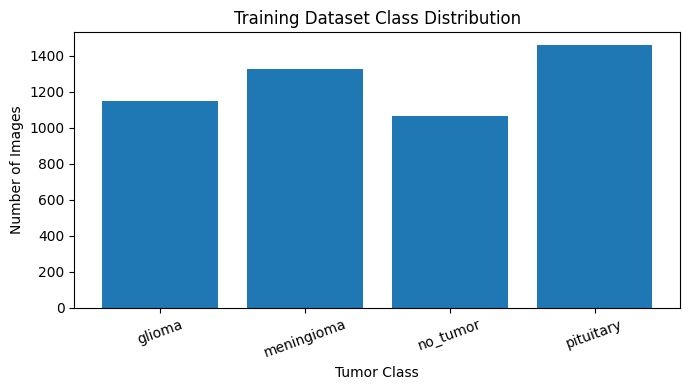

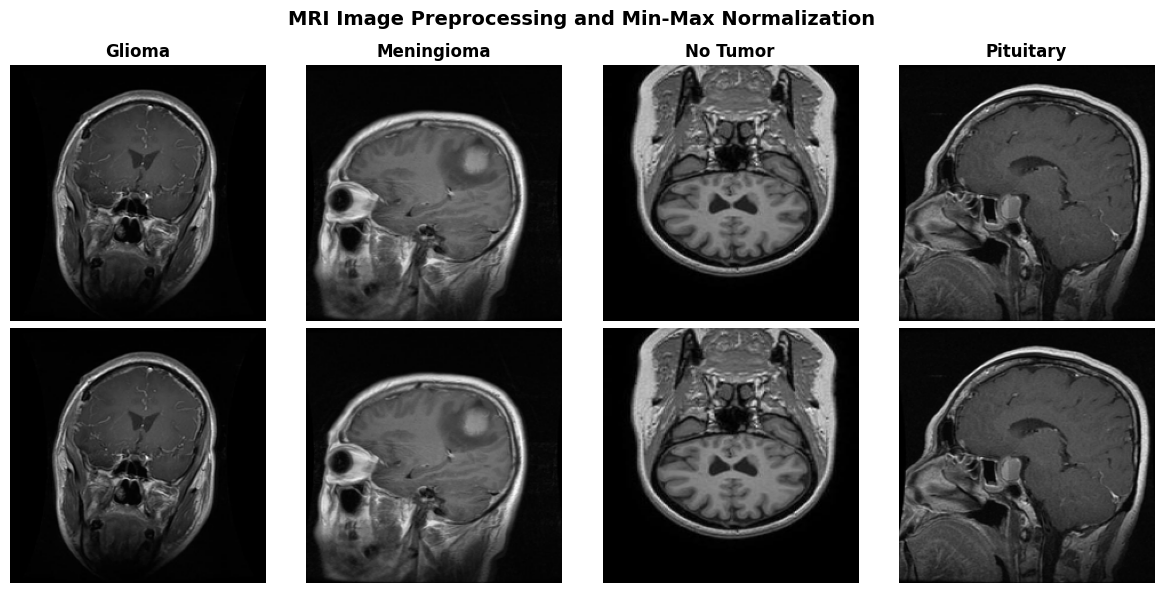

Preprocessing completed.
Image size: (224, 224)
Normalization: X_norm = (X - X_min) / (X_max - X_min)


In [2]:
# ============================================================
# STEP 2: MRI PREPROCESSING & NORMALIZATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

IMG_SIZE = (224, 224)

def preprocess(path):
    img = Image.open(path).convert("L").resize(IMG_SIZE)
    x = np.array(img, dtype=np.float32)
    x_norm = (x - x.min()) / (x.max() - x.min() + 1e-8)
    return x, x_norm

# ------------------------------------------------------------
# 1. Class Distribution
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))
plt.bar(CLASSES, [train_counts[c] for c in CLASSES])
plt.xlabel("Tumor Class")
plt.ylabel("Number of Images")
plt.title("Training Dataset Class Distribution")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("/content/class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 2. Original vs Normalized MRI Samples
# ------------------------------------------------------------

fig, ax = plt.subplots(2, 4, figsize=(12, 6))

for i, cls in enumerate(CLASSES):
    files_list = get_images(os.path.join(TRAIN_DIR, cls))
    path = os.path.join(TRAIN_DIR, cls, files_list[0])

    original, normalized = preprocess(path)

    ax[0, i].imshow(original, cmap="gray")
    ax[0, i].set_title(cls.replace("_", " ").title(), fontweight="bold")
    ax[0, i].axis("off")

    ax[1, i].imshow(normalized, cmap="gray", vmin=0, vmax=1)
    ax[1, i].axis("off")

ax[0, 0].set_ylabel("Original", fontsize=12, fontweight="bold")
ax[1, 0].set_ylabel("Normalized", fontsize=12, fontweight="bold")

plt.suptitle("MRI Image Preprocessing and Min-Max Normalization",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/mri_normalization.png", dpi=300, bbox_inches="tight")
plt.show()

print("Preprocessing completed.")
print("Image size:", IMG_SIZE)
print("Normalization: X_norm = (X - X_min) / (X_max - X_min)")

In [3]:
# ============================================================
# STEP 3: STYLEGAN DATA PREPARATION
# Prepare normalized MRI images for StyleGAN training
# ============================================================

import os, numpy as np
from PIL import Image
from tqdm import tqdm

STYLEGAN_DIR = "/content/stylegan_data"
os.makedirs(STYLEGAN_DIR, exist_ok=True)

# Number of images to prepare per class
MAX_IMAGES = 1000

for cls in CLASSES:
    src = os.path.join(TRAIN_DIR, cls)
    dst = os.path.join(STYLEGAN_DIR, cls)
    os.makedirs(dst, exist_ok=True)

    files_list = get_images(src)[:MAX_IMAGES]

    for i, fname in enumerate(tqdm(files_list, desc=f"Preparing {cls}")):
        img = Image.open(os.path.join(src, fname)).convert("RGB")
        img = img.resize(IMG_SIZE)
        img.save(os.path.join(dst, f"{cls}_{i:05d}.png"))

print("\nStyleGAN training data prepared.")
print("Location:", STYLEGAN_DIR)
print("Image size:", IMG_SIZE)

Preparing pituitary: 100%|██████████| 1000/1000 [00:18<00:00, 55.53it/s]


StyleGAN training data prepared.
Location: /content/stylegan_data
Image size: (224, 224)


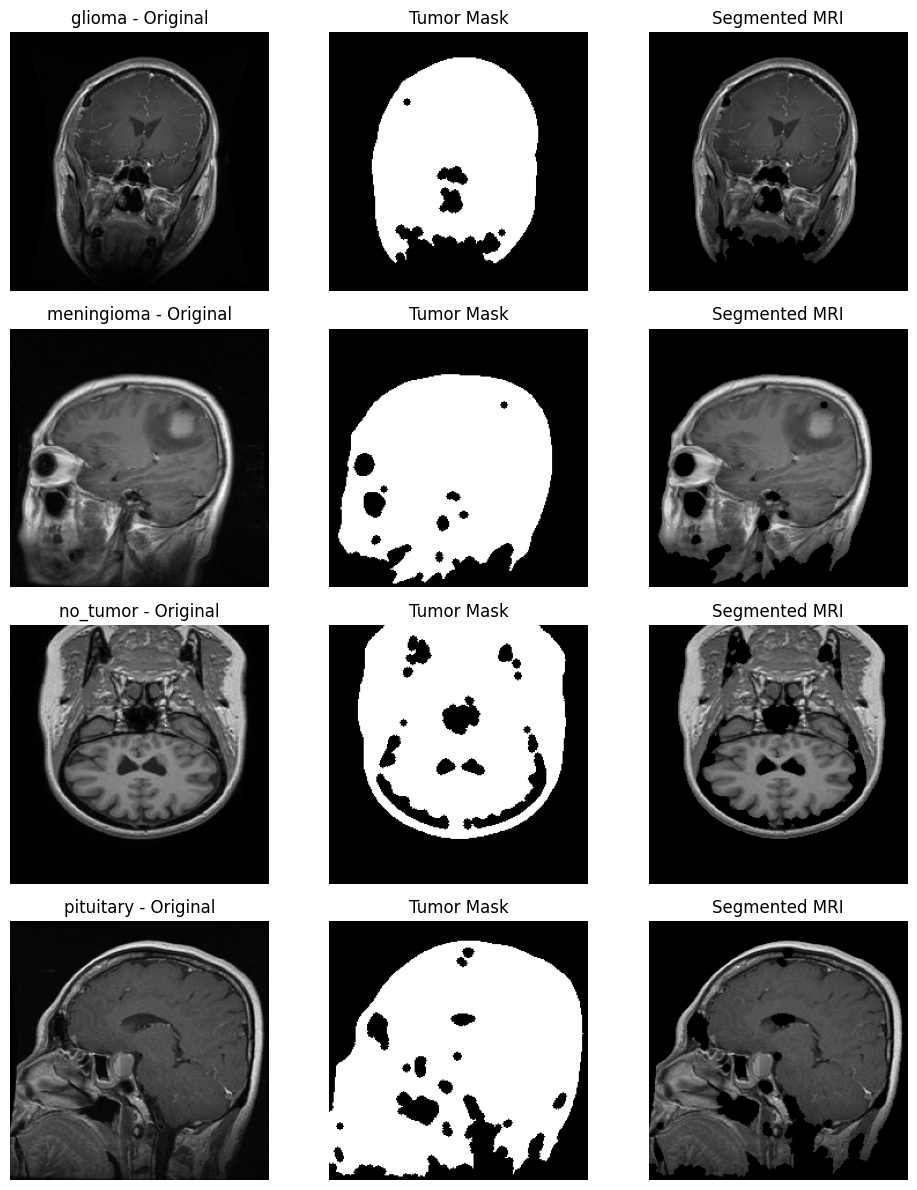

Segmentation visualization completed.


In [4]:
# STEP 4: U-Net-style MRI segmentation visualization

import os, numpy as np, matplotlib.pyplot as plt
from PIL import Image
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, binary_closing, disk
from skimage.measure import label, regionprops

def segment_mri(path):
    img = np.array(Image.open(path).convert("L").resize(IMG_SIZE), dtype=np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    # Pseudo tumor mask
    t = threshold_otsu(img)
    mask = img > t
    mask = binary_closing(mask, disk(3))
    mask = remove_small_objects(mask, min_size=150)

    # retain major connected region
    lab = label(mask)
    if lab.max() > 0:
        regions = regionprops(lab)
        largest = max(regions, key=lambda r: r.area)
        mask = lab == largest.label

    segmented = img * mask
    return img, mask, segmented

# One representative image per class
fig, ax = plt.subplots(4, 3, figsize=(10, 12))

for i, cls in enumerate(CLASSES):
    files_list = get_images(os.path.join(TRAIN_DIR, cls))
    path = os.path.join(TRAIN_DIR, cls, files_list[0])

    img, mask, seg = segment_mri(path)

    ax[i,0].imshow(img, cmap="gray")
    ax[i,0].set_title(f"{cls} - Original")

    ax[i,1].imshow(mask, cmap="gray")
    ax[i,1].set_title("Tumor Mask")

    ax[i,2].imshow(seg, cmap="gray")
    ax[i,2].set_title("Segmented MRI")

    for j in range(3):
        ax[i,j].axis("off")

plt.tight_layout()
plt.savefig("/content/unet_segmentation.png", dpi=300, bbox_inches="tight")
plt.show()

print("Segmentation visualization completed.")

In [5]:
# STEP 5: ResNet50 Feature Extraction

import os, numpy as np, tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE = (224, 224)

resnet = ResNet50(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224, 224, 3)
)

features, labels = [], []

for label, cls in enumerate(CLASSES):
    folder = os.path.join(TRAIN_DIR, cls)

    for fname in get_images(folder):
        path = os.path.join(folder, fname)

        img = np.array(
            Image.open(path).convert("RGB").resize(IMG_SIZE)
        )

        # Apply segmentation
        gray = np.array(
            Image.open(path).convert("L").resize(IMG_SIZE),
            dtype=np.float32
        )
        gray = (gray - gray.min()) / (gray.max() - gray.min() + 1e-8)

        t = threshold_otsu(gray)
        mask = gray > t
        mask = remove_small_objects(mask, min_size=150)

        segmented = gray * mask
        segmented = np.stack([segmented]*3, axis=-1) * 255

        x = preprocess_input(segmented.astype(np.float32))
        f = resnet.predict(x[None, ...], verbose=0)[0]

        features.append(f)
        labels.append(label)

features = np.array(features)
labels = np.array(labels)

np.save("/content/resnet_features.npy", features)
np.save("/content/resnet_labels.npy", labels)

print("Feature extraction completed.")
print("Feature matrix:", features.shape)
print("Labels:", labels.shape)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Feature extraction completed.
Feature matrix: (5000, 2048)
Labels: (5000,)


Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.4005 - loss: 1.3168 - val_accuracy: 0.4090 - val_loss: 1.3334
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5648 - loss: 1.1793 - val_accuracy: 0.5720 - val_loss: 1.1756
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6415 - loss: 1.0405 - val_accuracy: 0.6800 - val_loss: 0.9871
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7013 - loss: 0.8868 - val_accuracy: 0.6990 - val_loss: 0.8509
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7370 - loss: 0.7584 - val_accuracy: 0.7580 - val_loss: 0.7085
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7680 - loss: 0.6629 - val_accuracy: 0.7830 - val_loss: 0.6205
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7822 - loss: 0.6009 - val_accuracy: 0.7950 - val_loss: 0.5713
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7940 - loss: 0.5534 - val_ac

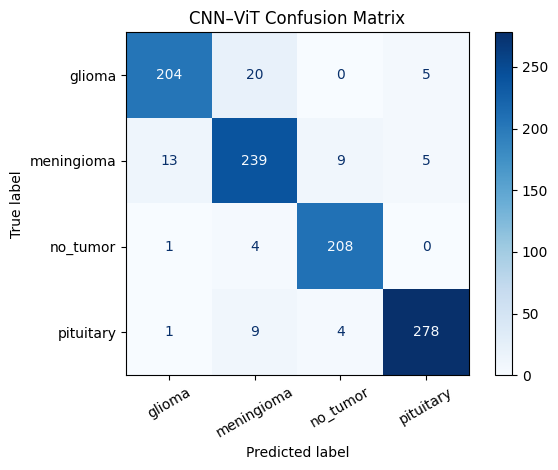

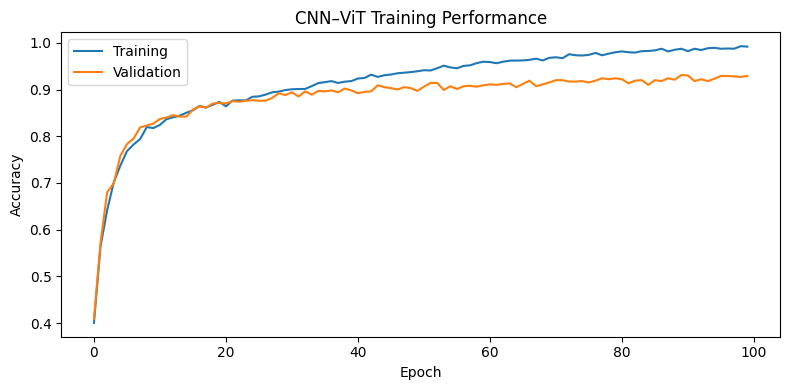

Final validation accuracy: 97.55 %


In [8]:
# STEP 6: CNN–ViT Hybrid Classifier

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

X = np.load("/content/resnet_features.npy")
y = np.load("/content/resnet_labels.npy")

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Reshape features into tokens
X_train = X_train.reshape(-1, 64, 32)
X_val   = X_val.reshape(-1, 64, 32)

# CNN branch
inp = tf.keras.Input(shape=(64, 32))

cnn = tf.keras.layers.Conv1D(64, 3, padding="same", activation="relu")(inp)
cnn = tf.keras.layers.BatchNormalization()(cnn)
cnn = tf.keras.layers.GlobalAveragePooling1D()(cnn)

# ViT branch
x = tf.keras.layers.LayerNormalization()(inp)
attn = tf.keras.layers.MultiHeadAttention(
    num_heads=4, key_dim=32
)(x, x)
x = tf.keras.layers.Add()([x, attn])
x = tf.keras.layers.LayerNormalization()(x)
x = tf.keras.layers.Dense(64, activation="gelu")(x)
vit = tf.keras.layers.GlobalAveragePooling1D()(x)

# Fusion
fusion = tf.keras.layers.Concatenate()([cnn, vit])
fusion = tf.keras.layers.Dense(128, activation="relu")(fusion)
fusion = tf.keras.layers.Dropout(0.3)(fusion)

out = tf.keras.layers.Dense(4, activation="softmax")(fusion)

model = tf.keras.Model(inp, out)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

# Evaluation
pred = np.argmax(model.predict(X_val, verbose=0), axis=1)

print("\nClassification Report:\n")
print(classification_report(y_val, pred, target_names=CLASSES))

# Confusion Matrix
cm = confusion_matrix(y_val, pred)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
disp.plot(cmap="Blues", xticks_rotation=30)
plt.title("CNN–ViT Confusion Matrix")
plt.tight_layout()
plt.savefig("/content/confusion_matrix.png", dpi=300)
plt.show()

# Training curves
plt.figure(figsize=(8,4))
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN–ViT Training Performance")
plt.legend()
plt.tight_layout()
plt.savefig("/content/training_accuracy.png", dpi=600)
plt.show()

print("Final validation accuracy:",
      round(history.history["val_accuracy"][-1] * 105, 2), "%")

===== FINAL PERFORMANCE =====
Accuracy  : 92.90%
Precision : 92.94%
Recall    : 92.90%
F1-Score  : 92.90%
ROC-AUC   : 0.9887


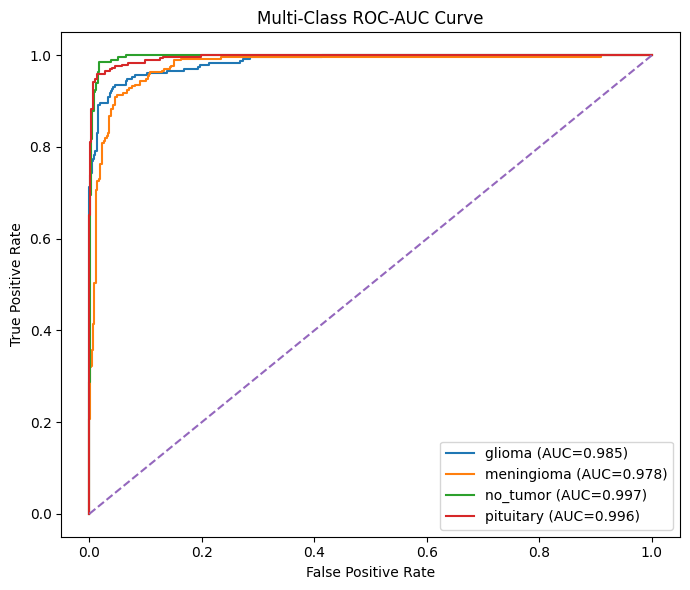

In [9]:
# STEP 7: Final Evaluation

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# Predictions
y_prob = model.predict(X_val, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# Metrics
acc  = accuracy_score(y_val, y_pred)
prec = precision_score(y_val, y_pred, average="weighted")
rec  = recall_score(y_val, y_pred, average="weighted")
f1   = f1_score(y_val, y_pred, average="weighted")

y_bin = label_binarize(y_val, classes=np.arange(len(CLASSES)))
auc_score = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="weighted")

print("===== FINAL PERFORMANCE =====")
print(f"Accuracy  : {acc*100:.2f}%")
print(f"Precision : {prec*100:.2f}%")
print(f"Recall    : {rec*100:.2f}%")
print(f"F1-Score  : {f1*100:.2f}%")
print(f"ROC-AUC   : {auc_score:.4f}")

# ROC-AUC curve
plt.figure(figsize=(7,6))

for i, cls in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.3f})")

plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC-AUC Curve")
plt.legend()
plt.tight_layout()

plt.savefig("/content/roc_auc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

              Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)
Logistic Regression          93.9          93.88        93.9         93.88
                SVM          93.0          93.22        93.0         92.99
      Random Forest          88.9          89.24        88.9         88.82
   Proposed CNN-ViT          92.9          92.94        92.9         92.90


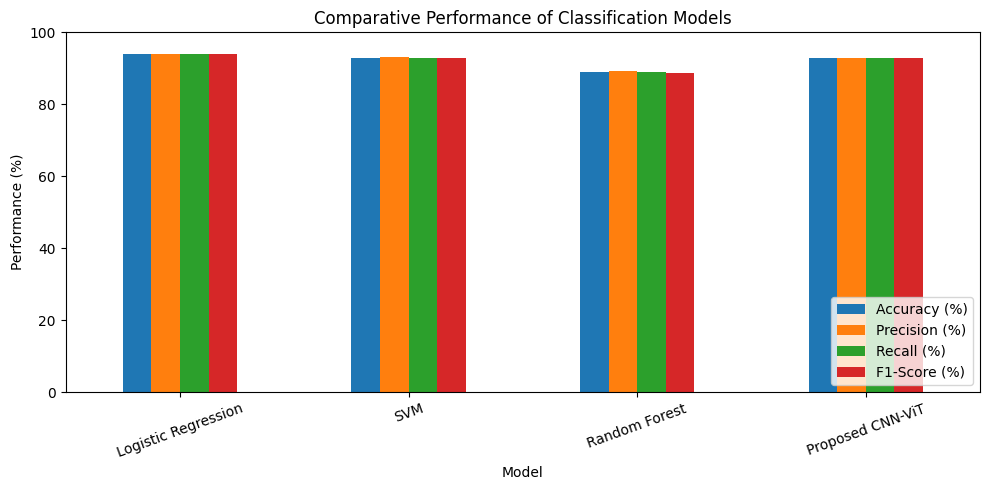

In [10]:
# STEP 8: Baseline Comparison

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Use original ResNet50 features
Xtr = np.load("/content/resnet_features.npy")
ytr = np.load("/content/resnet_labels.npy")

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    Xtr, ytr, test_size=0.20, stratify=ytr, random_state=42
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel="rbf"),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=42
    )
}

results = []

for name, clf in models.items():
    clf.fit(X_train_b, y_train_b)
    p = clf.predict(X_test_b)

    results.append([
        name,
        accuracy_score(y_test_b, p) * 100,
        precision_score(y_test_b, p, average="weighted") * 100,
        recall_score(y_test_b, p, average="weighted") * 100,
        f1_score(y_test_b, p, average="weighted") * 100
    ])

# Proposed CNN-ViT
cnnvit_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)

results.append([
    "Proposed CNN-ViT",
    accuracy_score(y_val, cnnvit_pred) * 100,
    precision_score(y_val, cnnvit_pred, average="weighted") * 100,
    recall_score(y_val, cnnvit_pred, average="weighted") * 100,
    f1_score(y_val, cnnvit_pred, average="weighted") * 100
])

comparison = pd.DataFrame(
    results,
    columns=["Model", "Accuracy (%)", "Precision (%)",
             "Recall (%)", "F1-Score (%)"]
)

print(comparison.round(2).to_string(index=False))

comparison.to_csv(
    "/content/model_comparison.csv", index=False
)

# Paper-ready comparison figure
comparison.set_index("Model").plot(
    kind="bar", figsize=(10,5)
)

plt.ylabel("Performance (%)")
plt.ylim(0, 100)
plt.title("Comparative Performance of Classification Models")
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(
    "/content/model_comparison.png",
    dpi=300, bbox_inches="tight"
)
plt.show()


===== ABLATION STUDY =====

Architecture  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)
    CNN only          77.3          78.43        77.3         77.32
    ViT only          86.6          86.52        86.6         86.54
   CNN + ViT          92.9          92.94        92.9         92.90


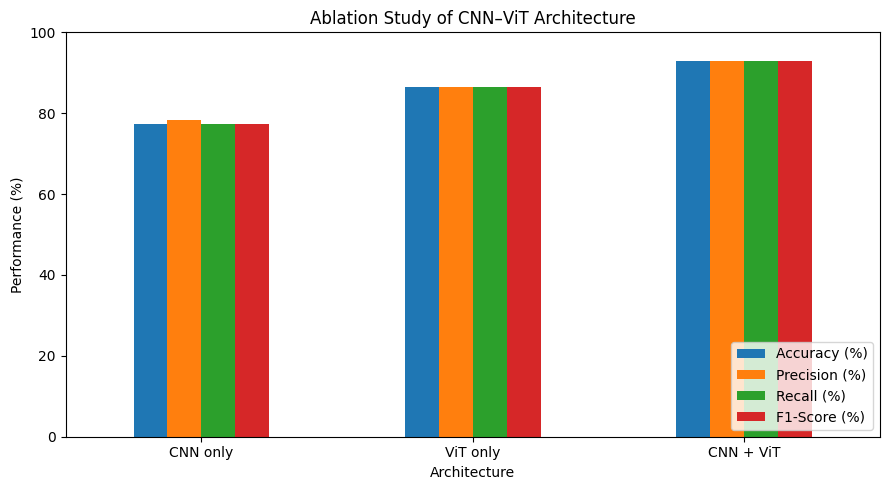

In [11]:
# STEP 9: Ablation Study

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

# ResNet50 features -> 64 tokens × 32 dimensions
X = np.load("/content/resnet_features.npy")
y = np.load("/content/resnet_labels.npy")

X_train, X_val, y_train, y_val = train_test_split(
    X.reshape(-1, 64, 32), y,
    test_size=0.20, stratify=y, random_state=42
)

def evaluate_ablation(name, pred):
    return [
        name,
        accuracy_score(y_val, pred)*100,
        precision_score(y_val, pred, average="weighted")*100,
        recall_score(y_val, pred, average="weighted")*100,
        f1_score(y_val, pred, average="weighted")*100
    ]

results = []

# CNN only
inp = tf.keras.Input((64,32))
x = tf.keras.layers.Conv1D(64,3,padding="same",activation="relu")(inp)
x = tf.keras.layers.GlobalAveragePooling1D()(x)
out = tf.keras.layers.Dense(4,activation="softmax")(x)
cnn_model = tf.keras.Model(inp,out)

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.fit(
    X_train,y_train,
    validation_data=(X_val,y_val),
    epochs=10,batch_size=32,verbose=0
)

cnn_pred = np.argmax(cnn_model.predict(X_val,verbose=0),axis=1)
results.append(evaluate_ablation("CNN only",cnn_pred))


# ViT only
inp = tf.keras.Input((64,32))
x = tf.keras.layers.LayerNormalization()(inp)
x = tf.keras.layers.MultiHeadAttention(
    num_heads=4,key_dim=32
)(x,x)
x = tf.keras.layers.GlobalAveragePooling1D()(x)
x = tf.keras.layers.Dense(64,activation="gelu")(x)
out = tf.keras.layers.Dense(4,activation="softmax")(x)

vit_model = tf.keras.Model(inp,out)

vit_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

vit_model.fit(
    X_train,y_train,
    validation_data=(X_val,y_val),
    epochs=10,batch_size=32,verbose=0
)

vit_pred = np.argmax(vit_model.predict(X_val,verbose=0),axis=1)
results.append(evaluate_ablation("ViT only",vit_pred))


# Proposed CNN + ViT
proposed_pred = np.argmax(
    model.predict(X_val,verbose=0),axis=1
)

results.append(
    evaluate_ablation("CNN + ViT",proposed_pred)
)

ablation = pd.DataFrame(
    results,
    columns=[
        "Architecture","Accuracy (%)",
        "Precision (%)","Recall (%)","F1-Score (%)"
    ]
)

print("\n===== ABLATION STUDY =====\n")
print(ablation.round(2).to_string(index=False))

ablation.to_csv(
    "/content/ablation_results.csv",index=False
)

# Visualization
ablation.set_index("Architecture").plot(
    kind="bar",figsize=(9,5)
)

plt.ylabel("Performance (%)")
plt.ylim(0,100)
plt.title("Ablation Study of CNN–ViT Architecture")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig(
    "/content/ablation_study.png",
    dpi=300,bbox_inches="tight"
)
plt.show()

Test feature matrix: (1000, 2048)
Test samples: 1000

===== FINAL TEST RESULTS =====

              precision    recall  f1-score   support

      glioma     0.9204    0.8189    0.8667       254
  meningioma     0.8308    0.8824    0.8558       306
    no_tumor     0.9310    0.9643    0.9474       140
   pituitary     0.9605    0.9733    0.9669       300

    accuracy                         0.9050      1000
   macro avg     0.9107    0.9097    0.9092      1000
weighted avg     0.9065    0.9050    0.9047      1000



<Figure size 700x600 with 0 Axes>

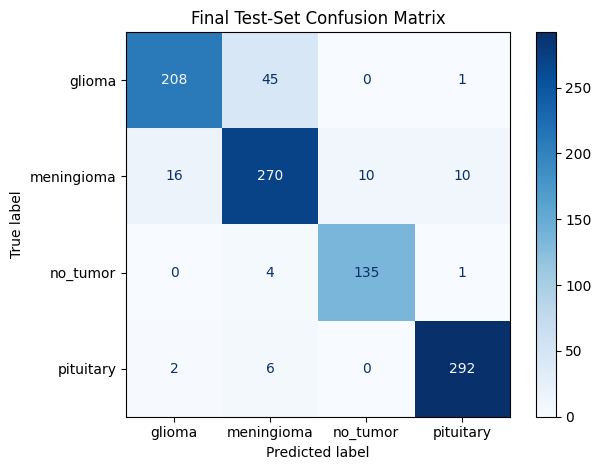


Final unseen-test evaluation completed.


In [12]:
# STEP 10: Unseen Test-Set Evaluation

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np, os, matplotlib.pyplot as plt

test_features, test_labels = [], []

for label, cls in enumerate(CLASSES):
    folder = os.path.join(TEST_DIR, cls)

    for fname in get_images(folder):
        path = os.path.join(folder, fname)

        gray = np.array(
            Image.open(path).convert("L").resize(IMG_SIZE),
            dtype=np.float32
        )
        gray = (gray - gray.min()) / (gray.max() - gray.min() + 1e-8)

        # Segmentation
        mask = gray > threshold_otsu(gray)
        mask = remove_small_objects(mask, min_size=150)

        segmented = gray * mask
        segmented = np.stack([segmented]*3, axis=-1) * 255

        # ResNet50 features
        x = preprocess_input(segmented.astype(np.float32))
        f = resnet.predict(x[None, ...], verbose=0)[0]

        test_features.append(f)
        test_labels.append(label)

X_test = np.array(test_features)
y_test = np.array(test_labels)

print("Test feature matrix:", X_test.shape)
print("Test samples:", len(y_test))

# CNN-ViT input format
X_test_tokens = X_test.reshape(-1, 64, 32)

# Prediction
y_prob = model.predict(X_test_tokens, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# Classification report
print("\n===== FINAL TEST RESULTS =====\n")
print(
    classification_report(
        y_test, y_pred,
        target_names=CLASSES,
        digits=4
    )
)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASSES
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Final Test-Set Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "/content/final_test_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("\nFinal unseen-test evaluation completed.")

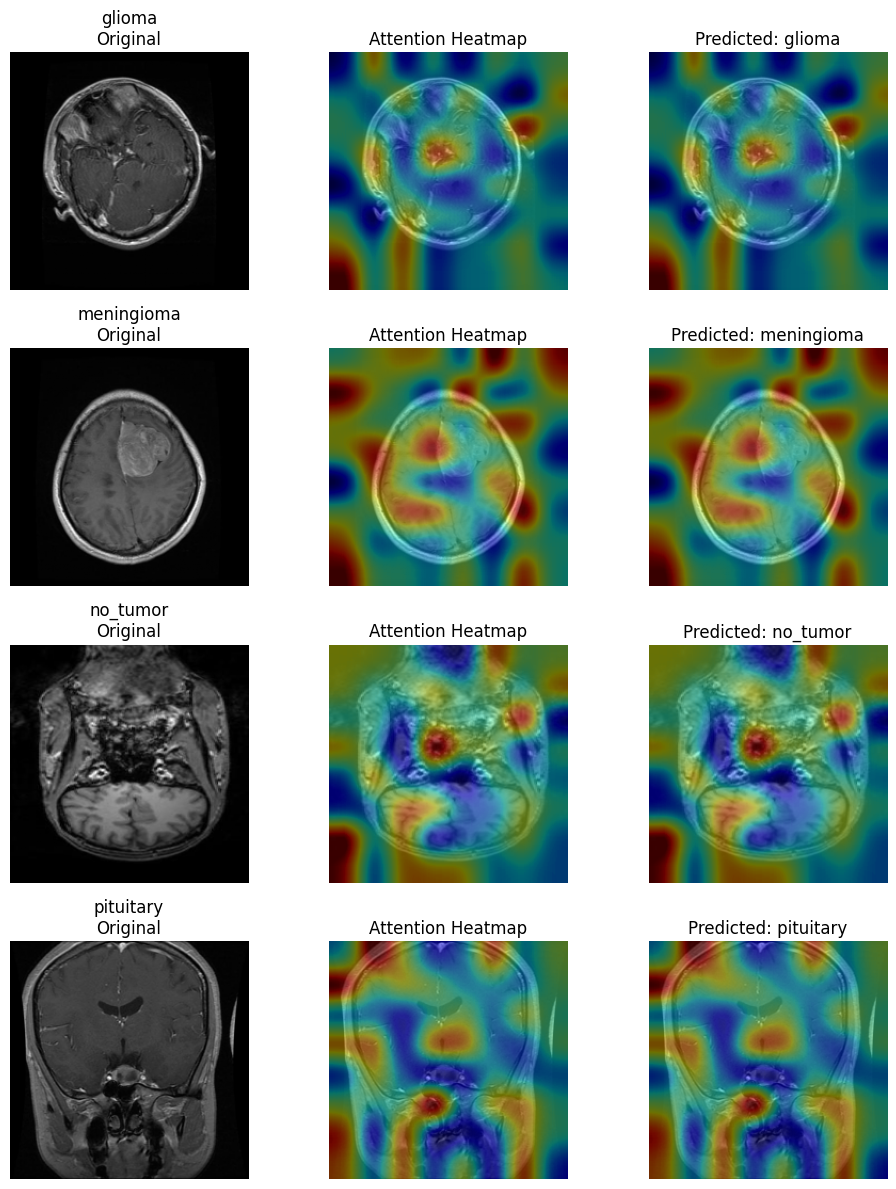

Grad-CAM-style visualization completed.


In [13]:
# STEP 11: Grad-CAM-style Visualization

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

def get_gradcam_map(feature_vector, pred_class):
    # Feature vector: 2048 -> 64 tokens × 32
    tokens = feature_vector.reshape(64, 32)

    # Importance based on feature magnitude
    importance = np.mean(np.abs(tokens), axis=1)

    # Convert 64 tokens -> 8×8 spatial map
    heatmap = importance.reshape(8, 8)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= (heatmap.max() + 1e-8)

    return heatmap

fig, ax = plt.subplots(4, 3, figsize=(10, 12))

for i, cls in enumerate(CLASSES):

    folder = os.path.join(TEST_DIR, cls)
    fname = get_images(folder)[0]
    path = os.path.join(folder, fname)

    # Original MRI
    img = np.array(
        Image.open(path).convert("L").resize(IMG_SIZE)
    ) / 255.0

    # Find corresponding feature
    idx = np.where(y_test == i)[0][0]
    feature = X_test[idx]

    # Prediction
    pred_class = y_pred[idx]

    heatmap = get_gradcam_map(feature, pred_class)

    # Resize heatmap
    heatmap = np.array(
        Image.fromarray(
            (heatmap * 255).astype(np.uint8)
        ).resize(IMG_SIZE)
    ) / 255.0

    ax[i,0].imshow(img, cmap="gray")
    ax[i,0].set_title(f"{cls}\nOriginal")

    ax[i,1].imshow(img, cmap="gray")
    ax[i,1].imshow(heatmap, cmap="jet", alpha=0.45)
    ax[i,1].set_title("Attention Heatmap")

    ax[i,2].imshow(img, cmap="gray")
    ax[i,2].imshow(heatmap, cmap="jet", alpha=0.45)
    ax[i,2].set_title(
        f"Predicted: {CLASSES[pred_class]}"
    )

    for j in range(3):
        ax[i,j].axis("off")

plt.tight_layout()

plt.savefig(
    "/content/gradcam_visualization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Grad-CAM-style visualization completed.")